---
title: "Portafolio Test"
subtitle: "Portafolio"
author:   
    - name: "Equipo portafolio"
date: "2025-05-10"
format:
  html:
    html-math-method: mathml
    toc: true
    toc-depth: 3
    toc-location: right
    toc-title: "Contenido"
    self-contained: true
  pdf:
    toc: true
    toc-depth: 3
    toc-title: "Contenido"
number-sections: true
---

# Portfolio Test

In [1]:
import pandas as pd
import numpy as np

In [3]:
from src.backtesting import (
    BacktestConfig,
    RebalanceConfig
)

from src.optimization import (
    MinimumVarianceConfig,
    MinimumSemivarianceConfig,
    OptimizationConfig,
    MaximumOmegaConfig
)

from src.backtesting import ( 
    PostModernStrategy,
    MeanVarianceStrategy,
)

from src.backtesting import (
    DynamicBacktestEngine
)

from src.selection import FundamentalSelector

from src.research import AssetsResearch

In [5]:
tickets = [
    # CORE
    "WELL", # Helcare ()
    "AAPL", # Tec
    "MELI", # No-Discrecional
    "WMT",  # No-Discrecional
    "LMT",  # Industry 
    "PARR", # Energy (se mete), 2012
    "WDC",  # 
    "AXP"   #
    # "TSM",  # Industry (se saca)
    
    # Satelite
    # "CRML", # Industry
    # "IONQ", # Procesadores cuanticos
    # "COPN"  # Helcare Famaseutica 

    #Benchmark
    # "EMV.L"
    # "VOO", #Benchmark
    

]

# tickets_d = [
    # "FIBRAPL14.MX",
    # "AAPL",
    # "BLK",
    # "BRK-B",
    # "KAP.L",
    # "REGN",
    # "GLTR",
    # "EMVL.L"
# ]


In [6]:
#
max_allocation = 0.30

#
min_allocation = 0.075

min_return = 0.17

n_activos = len(tickets)


strategies = [
    PostModernStrategy(
        objective="minimum_semivariance",
        config=MinimumSemivarianceConfig(
            threshold=0,
            minimum_return=min_return,
            bounds=[(min_allocation, max_allocation)] * n_activos,
        ),
    ),
    
    PostModernStrategy(
        objective="maximum_omega",
        config=MaximumOmegaConfig(
            threshold=0,
            bounds=[(min_allocation, max_allocation)] * n_activos,
        ),
    ),
    
    MeanVarianceStrategy(
        objective="minimum_variance",
        config=MinimumVarianceConfig(
            risk_free_rate=0.045,
            minimum_return=min_return,
            bounds=[(min_allocation, max_allocation)] * n_activos,
        ),
    ),
    
    MeanVarianceStrategy(
        objective="maximum_sharpe",
        config=OptimizationConfig(
            risk_free_rate=min_return,
            bounds=[(min_allocation, max_allocation)] * n_activos,
        ),
    ),
]

In [7]:
start_date = "2016-01-01"
end_date = "2026-05-01"

In [8]:
Assets = AssetsResearch(tickers=tickets, start=start_date, end=end_date)

benchmark = AssetsResearch(tickers=["VOO"], start=start_date, end=end_date)

benchmark_prices = benchmark.get_prices()
assets_prices = Assets.get_prices()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


In [9]:
assets_prices.head()

Ticker,AAPL,AXP,LMT,MELI,PARR,WDC,WELL,WMT
Date,,,,,,,,
2016-01-04,23.730946,58.229328,162.375122,109.231094,23.100000,39.230022,46.534073,17.007477
2016-01-05,23.136265,57.333370,166.221085,108.962875,24.000000,39.061150,47.690777,17.411495
2016-01-06,22.683498,55.741234,165.741272,106.628235,23.790001,38.190807,47.588726,17.585829
2016-01-07,21.726149,55.239388,162.436081,102.256989,23.610001,37.560795,46.227871,17.995380
2016-01-08,21.841036,55.057671,162.146637,100.429039,23.719999,35.975994,46.329945,17.583065


In [10]:
benchmark_prices.head()

Ticker,VOO
Date,
2016-01-04,155.079849
2016-01-05,155.357605
2016-01-06,153.388687
2016-01-07,149.652771
2016-01-08,148.062546


In [11]:
assets_prices.index[0]

Timestamp('2016-01-04 00:00:00')

In [12]:
start_date = assets_prices.index[0]
window_back_test = "2017-01-01"

In [ ]:
BacktestConfigValue = BacktestConfig(
    tickers = tickets,
    initial_capital = 1_000_000,
    optimization_start = start_date,
    backtest_start = window_back_test,
    end = end_date,
    risk_free_rate=0.045,
    benchmark_ticker="SPY"
)

rebalance_config = RebalanceConfig(
    lookback_months  = 12,      #Se toman para cada ventana de back 12 meses
    rebalance_months = 3,       #Se revalancea cada 3 meses
    expanding_window = False,   #Ventana movil de 12 meses
    transaction_cost = 0        #Costos de transacción 
)

In [ ]:
DynamicBacktestEngineValue = DynamicBacktestEngine(
    config=BacktestConfigValue,
    rebalance_config=rebalance_config
)

results_value = DynamicBacktestEngineValue.run(
    strategies=strategies,
    prices=assets_prices
)

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


<Axes: >

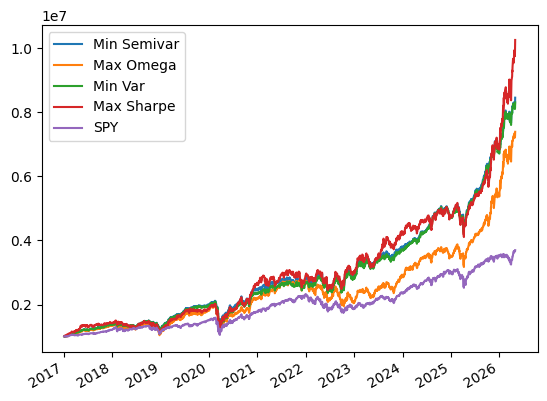

In [15]:
results_value.evolution.plot()

In [16]:
results_value.metrics.round(decimals=4)

,Min Semivar,Max Omega,Min Var,Max Sharpe,SPY
Rendimiento esperado,0.2494,0.2417,0.2478,0.2785,0.1575
Rendimiento realizado,7.4521,6.3873,7.3056,9.2516,2.6955
Volatilidad,0.1976,0.2297,0.1988,0.2363,0.1835
Ratio de sharpe,1.0345,0.8564,1.0199,0.9881,0.6132
Downside risk,0.1276,0.1440,0.1291,0.1462,0.1183
Upside risk,0.1202,0.1400,0.1208,0.1444,0.1125
Omega,0.9417,0.9724,0.9356,0.9877,0.9507
Beta,0.9032,1.0446,0.8967,1.0546,1.0000
Alpha de Jensen,0.1028,0.0792,0.1019,0.1149,-0.0000
Ratio de Treynor,0.2263,0.1883,0.2261,0.2214,0.1125


In [17]:
name_strategy = "Min Semivar"

weight_min_semivar = results_value.weights_history.loc[
    results_value.weights_history["strategy"] == name_strategy, :
].round(decimals=4).iloc[:, 1:] * 1_000_000 / 1_000_000

In [18]:
weight_min_semivar 

,WELL,AAPL,MELI,WMT,LMT,PARR,WDC,AXP
date,,,,,,,,
2017-01-03,0.0750,0.0750,0.1444,0.1806,0.3000,0.0750,0.0750,0.0750
2017-04-03,0.1017,0.0979,0.0750,0.2003,0.3000,0.0750,0.0750,0.0750
2017-07-03,0.1012,0.1313,0.0750,0.1878,0.2126,0.0750,0.0750,0.1420
2017-10-03,0.0998,0.0750,0.0750,0.1540,0.2826,0.0856,0.0750,0.1530
2018-01-03,0.0971,0.0750,0.0750,0.1539,0.2613,0.0750,0.0750,0.1877
2018-04-03,0.1307,0.0774,0.0750,0.1144,0.3000,0.1200,0.0750,0.1077
2018-07-03,0.0750,0.3000,0.1335,0.0750,0.0750,0.0750,0.0750,0.1915
2018-10-03,0.1849,0.2192,0.0750,0.1142,0.1398,0.0750,0.0750,0.1169
2019-01-03,0.3000,0.0750,0.2500,0.0750,0.0750,0.0750,0.0750,0.0750


In [19]:
weight_min_semivar.describe() * 100

,WELL,AAPL,MELI,WMT,LMT,PARR,WDC,AXP
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,14.016842,10.449474,8.560263,20.186842,20.939211,9.661053,7.504737,8.681053
std,8.272474,5.863732,3.187097,8.242823,7.939025,5.379671,0.029200,3.047856
min,7.500000,7.500000,7.500000,7.500000,7.500000,7.500000,7.500000,7.500000
25%,7.500000,7.500000,7.500000,14.047500,14.777500,7.500000,7.500000,7.500000
50%,10.050000,7.500000,7.500000,19.515000,21.995000,7.500000,7.500000,7.500000
75%,19.975000,10.792500,7.500000,29.235000,29.565000,7.500000,7.500000,7.500000
max,30.000000,30.000000,25.000000,30.000000,30.000000,30.000000,7.680000,19.150000


In [20]:
results_value.transaction_costs.sum()

Min Semivar     96840.953921
Max Omega      169610.482634
Min Var         83155.661236
Max Sharpe     193643.734710
dtype: float64

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _weights_for_strategy(weights_history, strategy=None):
    weights_history = weights_history.copy()

    if "strategy" in weights_history.columns:
        strategies = weights_history["strategy"].dropna().unique()

        if strategy is None and len(strategies) > 1:
            raise ValueError(
                f"Hay varias estrategias: {list(strategies)}. "
                "Pasa strategy='nombre_estrategia'."
            )

        if strategy is not None:
            weights_history = weights_history[weights_history["strategy"] == strategy]

    return weights_history


def correlation_matrices_over_backtest(
    result,
    strategy=None,
    weighted=False,
    absolute=False,
    normalize_weighted=False,
):
    matrices = {}

    prices = result.prices
    optimization_start = pd.Timestamp(result.config.optimization_start)
    rebalance_config = result.rebalance_config
    weights_history = _weights_for_strategy(result.weights_history, strategy=strategy)

    rebalance_dates = pd.DatetimeIndex(weights_history.index.unique()).sort_values()

    for rebalance_date in rebalance_dates:
        rebalance_date = pd.Timestamp(rebalance_date)

        if rebalance_config.expanding_window:
            start = optimization_start
        else:
            start = max(
                optimization_start,
                rebalance_date - pd.DateOffset(months=rebalance_config.lookback_months),
            )

        training_prices = prices.loc[
            (prices.index >= start) & (prices.index < rebalance_date)
        ]

        returns = training_prices.pct_change().dropna()
        corr = returns.corr()

        if absolute:
            corr = corr.abs()

        if not weighted:
            matrices[rebalance_date] = corr
            continue

        weights_row = weights_history.loc[rebalance_date]

        if isinstance(weights_row, pd.DataFrame):
            weights_row = weights_row.iloc[0]

        weights = (
            weights_row
            .drop(labels=["strategy"], errors="ignore")
            .reindex(corr.columns)
            .fillna(0.0)
            .astype(float)
        )

        pair_weights = pd.DataFrame(
            np.outer(weights, weights),
            index=corr.index,
            columns=corr.columns,
        )

        weighted_matrix = corr * pair_weights

        if normalize_weighted:
            mask = ~np.eye(len(weighted_matrix), dtype=bool)
            denominator = pair_weights.to_numpy()[mask].sum()

            if not np.isclose(denominator, 0.0):
                weighted_matrix = weighted_matrix / denominator

        matrices[rebalance_date] = weighted_matrix

    return matrices


In [22]:
results_value.weights_history

,strategy,WELL,AAPL,MELI,WMT,LMT,PARR,WDC,AXP
date,,,,,,,,,
2017-01-03,Min Semivar,0.075000,0.07500,0.144356,0.180644,0.300000,0.075000,0.075000,0.075000
2017-04-03,Min Semivar,0.101735,0.09793,0.075000,0.200335,0.300000,0.075000,0.075000,0.075000
2017-07-03,Min Semivar,0.101174,0.13132,0.075000,0.187845,0.212612,0.075000,0.075000,0.142048
2017-10-03,Min Semivar,0.099762,0.07500,0.075000,0.153954,0.282647,0.085598,0.075000,0.153040
2018-01-03,Min Semivar,0.097131,0.07500,0.075000,0.153852,0.261321,0.075000,0.075000,0.187697
...,...,...,...,...,...,...,...,...,...
2025-04-03,Max Sharpe,0.300000,0.07500,0.075000,0.250000,0.075000,0.075000,0.075000,0.075000
2025-07-03,Max Sharpe,0.300000,0.07500,0.206295,0.118705,0.075000,0.075000,0.075000,0.075000
2025-10-03,Max Sharpe,0.183737,0.07500,0.075000,0.075000,0.075000,0.141263,0.300000,0.075000


In [23]:
corr_by_date = _weights_for_strategy(results_value.weights_history, strategy="Min Semivar")

corr_by_date

,strategy,WELL,AAPL,MELI,WMT,LMT,PARR,WDC,AXP
date,,,,,,,,,
2017-01-03,Min Semivar,0.075000,0.075000,0.144356,0.180644,0.300000,0.075000,0.07500,0.075000
2017-04-03,Min Semivar,0.101735,0.097930,0.075000,0.200335,0.300000,0.075000,0.07500,0.075000
2017-07-03,Min Semivar,0.101174,0.131320,0.075000,0.187845,0.212612,0.075000,0.07500,0.142048
2017-10-03,Min Semivar,0.099762,0.075000,0.075000,0.153954,0.282647,0.085598,0.07500,0.153040
2018-01-03,Min Semivar,0.097131,0.075000,0.075000,0.153852,0.261321,0.075000,0.07500,0.187697
2018-04-03,Min Semivar,0.130665,0.077355,0.075000,0.114360,0.300000,0.119964,0.07500,0.107657
2018-07-03,Min Semivar,0.075000,0.300000,0.133512,0.075000,0.075000,0.075000,0.07500,0.191488
2018-10-03,Min Semivar,0.184855,0.219232,0.075000,0.114191,0.139844,0.075000,0.07500,0.116878
2019-01-03,Min Semivar,0.300000,0.075000,0.250000,0.075000,0.075000,0.075000,0.07500,0.075000


In [24]:
result_ = correlation_matrices_over_backtest(result=results_value, weighted=True, strategy="Min Semivar", absolute=True)

date = pd.to_datetime("2022-02-14 00:00:00")



In [25]:
result_[date]

KeyError: Timestamp('2022-02-14 00:00:00')

In [ ]:
def weighted_mean_correlation_over_backtest(result, strategy=None, absolute=False):
    corr_by_date = correlation_matrices_over_backtest(
        result,
        strategy=strategy,
        weighted=False,
        absolute=absolute,
    )

    weights_history = _weights_for_strategy(result.weights_history, strategy=strategy)

    weighted_corr = {}

    for date, corr in corr_by_date.items():
        weights_row = weights_history.loc[date]

        if isinstance(weights_row, pd.DataFrame):
            weights_row = weights_row.iloc[0]

        weights = (
            weights_row
            .drop(labels=["strategy"], errors="ignore")
            .reindex(corr.columns)
            .fillna(0.0)
            .astype(float)
        )

        C = corr.to_numpy()
        w = weights.to_numpy()

        mask = ~np.eye(len(C), dtype=bool)
        pair_weights = np.outer(w, w)

        denominator = pair_weights[mask].sum()

        if np.isclose(denominator, 0.0):
            weighted_corr[date] = np.nan
        else:
            weighted_corr[date] = (
                C[mask] * pair_weights[mask]
            ).sum() / denominator

    return pd.Series(weighted_corr, name="weighted_mean_correlation").sort_index()


<Axes: title={'center': 'Correlación promedio ponderada'}>

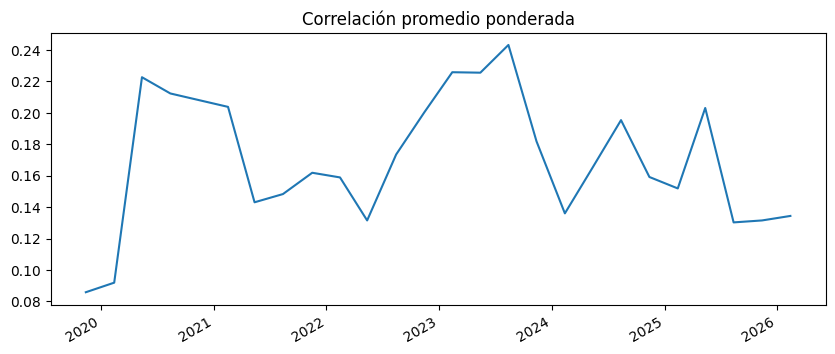

In [ ]:
weighted_corr = weighted_mean_correlation_over_backtest(
    results_value,
    strategy="Min Semivar",
    # absolute=False,
)
weighted_corr.plot(figsize=(10, 4), title="Correlación promedio ponderada")
